Для выполнения ИКМ был взят датасет exchange с сайта kaggle.com (https://www.kaggle.com/datasets/limpidcloud/datasets-for-multivariate-time-series-forecasting?resource=download&select=exchange.csv). 

Данный набор данных представляет собой коллекцию ежедневных обменных курсов восьми стран: Австралии, Великобритании, Канады, Швейцарии, Китая, Японии, Новой Зеландии и Сингапура, за период с 1990 по 2016 год.

Импорт библиотек

In [42]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import GRU

plt.style.use('seaborn-v0_8')

## Исследование данных.

1. Загрузка и описание датасета

In [44]:
df = pd.read_csv('data/exchange.csv')

df.head()

,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD
0,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.5930,0.525486
1,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.5940,0.523972
2,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.5973,0.526316
3,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.5970,0.523834
4,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.5985,0.527426


Датасет содержит временные ряды валютных курсов для 8 валют:

AUD — Австралийский доллар

GBP — Британский фунт

CAD — Канадский доллар

CHF — Швейцарский франк

CNY — Китайский юань

JPY — Японская иена

NZD — Новозеландский доллар

SGD — Сингапурский доллар

Каждый столбец представляет отдельный временной ряд.

2. Размер выборки

In [45]:
print("Размер выборки:", df.shape)

Размер выборки: (7588, 8)


3. Описание признаков

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AUD     7588 non-null   float64
 1   GBP     7588 non-null   float64
 2   CAD     7588 non-null   float64
 3   CHF     7588 non-null   float64
 4   CNY     7588 non-null   float64
 5   JPY     7588 non-null   float64
 6   NZD     7588 non-null   float64
 7   SGD     7588 non-null   float64
dtypes: float64(8)
memory usage: 474.4 KB


In [47]:
df.describe()

,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD
count,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000,7588.000000
mean,0.776974,1.634105,0.821811,0.848146,0.142833,0.009343,0.654418,0.669673
std,0.136620,0.161544,0.117123,0.168874,0.023996,0.001458,0.115292,0.082836
min,0.483297,1.211534,0.618582,0.548617,0.109292,0.006254,0.393153,0.523834
25%,0.701422,1.532887,0.727901,0.696864,0.120814,0.008331,0.566000,0.593287
50%,0.761377,1.606574,0.811582,0.813959,0.145212,0.009151,0.669187,0.662767
75%,0.873477,1.707646,0.920394,1.014018,0.159948,0.009995,0.734901,0.731835
max,1.102536,2.109000,1.091524,1.374079,0.237954,0.013202,0.882379,0.832556


Данные представляют значения валютных курсов во времени.

Все признаки являются числовыми (float64), пропущенных значений нет.

4. Проверка на стационарность

In [48]:
alpha = 0.05

for column in df.columns:

    name = column

    ts = df[column]

    print(f'Тест Дики-Фуллера ряда {name} :')

    dftest = adfuller(ts, autolag='AIC')

    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            'Test Statistic',
            'p-value',
            '#Lags Used',
            'Number of Observations Used'
        ]
    )

    display(dfoutput)

    if dfoutput["p-value"] < alpha:
        print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.\n")
    else:
        print(f"Значение p больше {alpha * 100}%. Ряд не стационарный.\n")

Тест Дики-Фуллера ряда AUD :


Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
dtype: float64

Значение p больше 5.0%. Ряд не стационарный.

Тест Дики-Фуллера ряда GBP :


Test Statistic                   -2.149718
p-value                           0.224998
#Lags Used                       14.000000
Number of Observations Used    7573.000000
dtype: float64

Значение p больше 5.0%. Ряд не стационарный.

Тест Дики-Фуллера ряда CAD :


...

Значение p больше 5.0%. Ряд не стационарный.

Тест Дики-Фуллера ряда NZD :


Test Statistic                   -1.728197
p-value                           0.416646
#Lags Used                        3.000000
Number of Observations Used    7584.000000
dtype: float64

Значение p больше 5.0%. Ряд не стационарный.

Тест Дики-Фуллера ряда SGD :


Test Statistic                   -1.747735
p-value                           0.406701
#Lags Used                       17.000000
Number of Observations Used    7570.000000
dtype: float64

Значение p больше 5.0%. Ряд не стационарный.



Проверка стационарности временных рядов была выполнена с помощью теста Дики-Фуллера. Для большинства признаков p-value оказалось больше уровня значимости 0.05, следовательно, ряды являются нестационарными.

5. Визуализация временных рядов

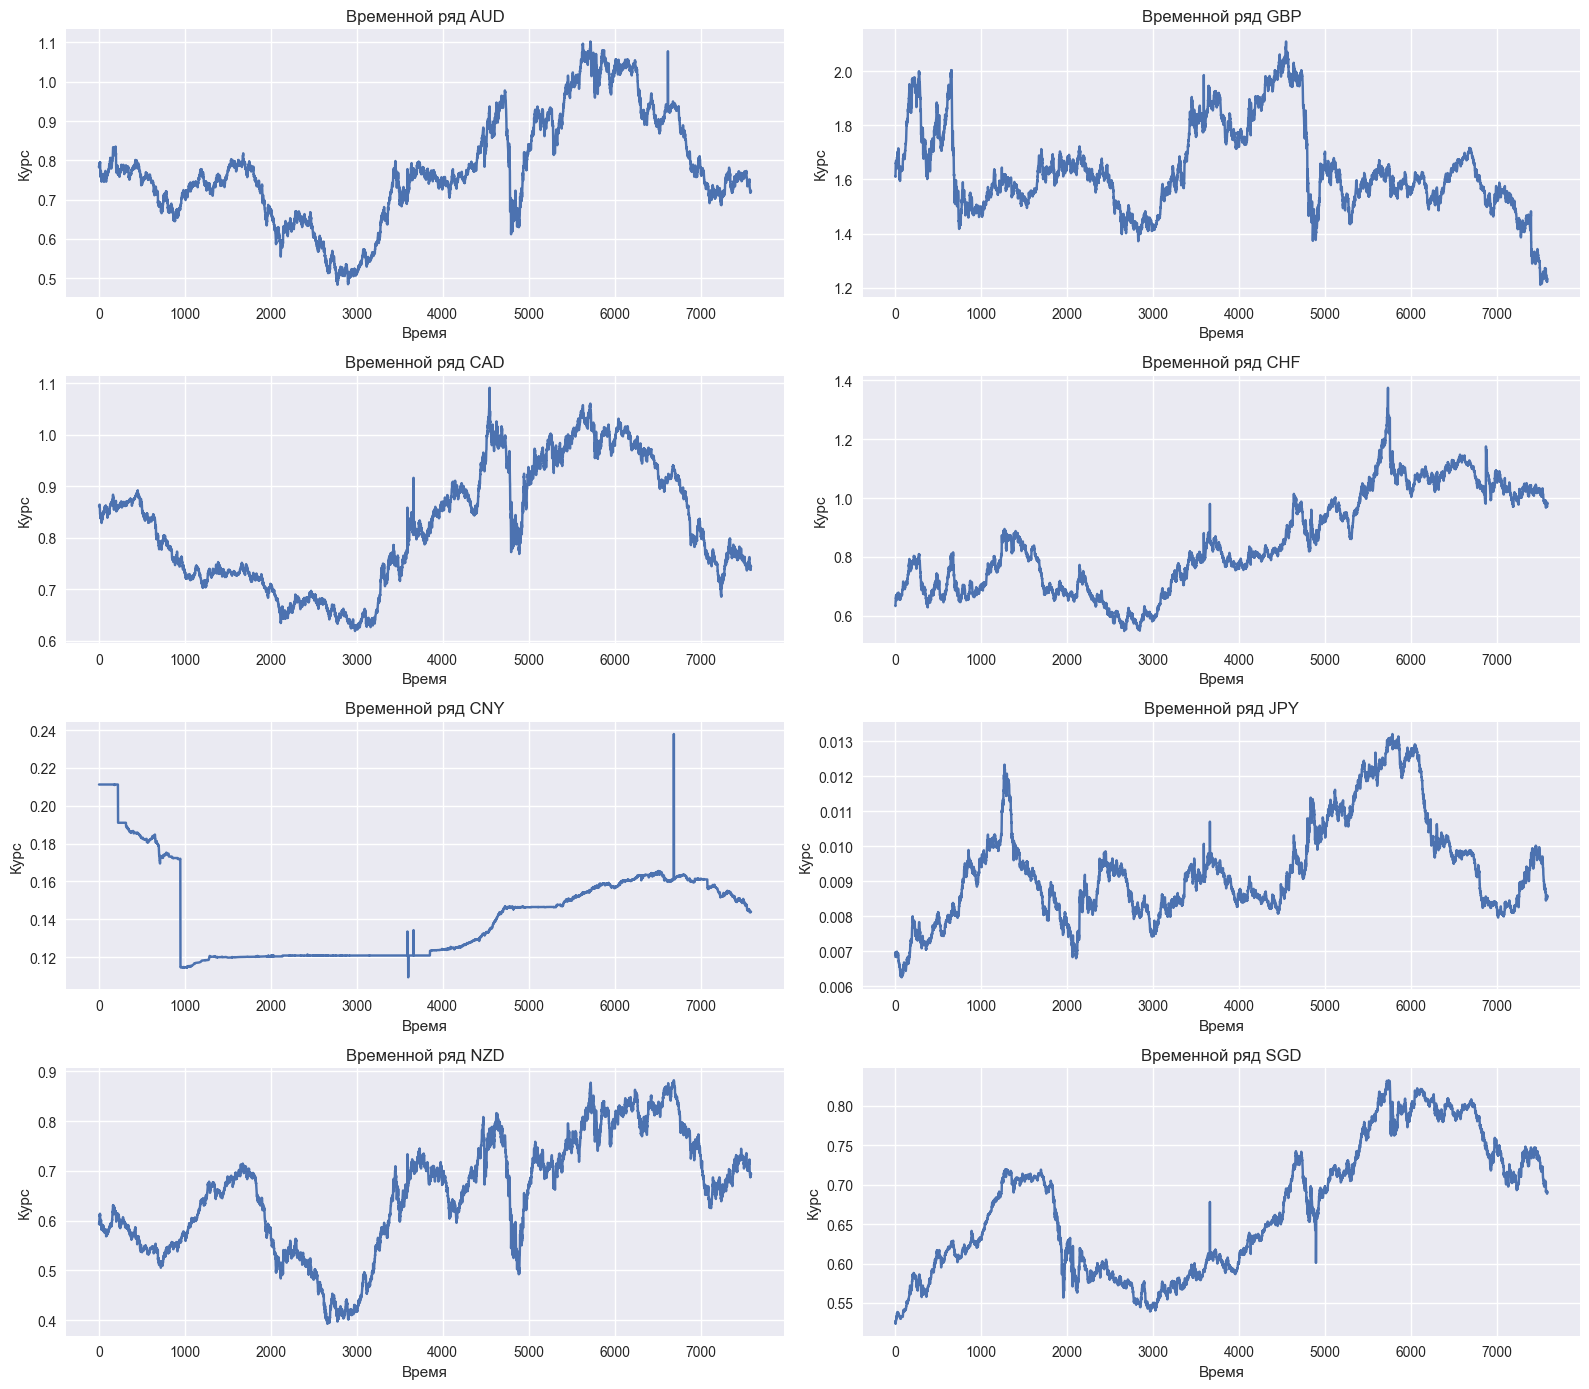

In [49]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))

axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(df[col])
    axes[i].set_title(f'Временной ряд {col}')
    axes[i].set_xlabel('Время')
    axes[i].set_ylabel('Курс')

plt.tight_layout()
plt.show()

## Предобработка временного ряда

Прогнозирования курса CHF (Швейцарского франка) по остальным валютам и прошлым значениям ряда.

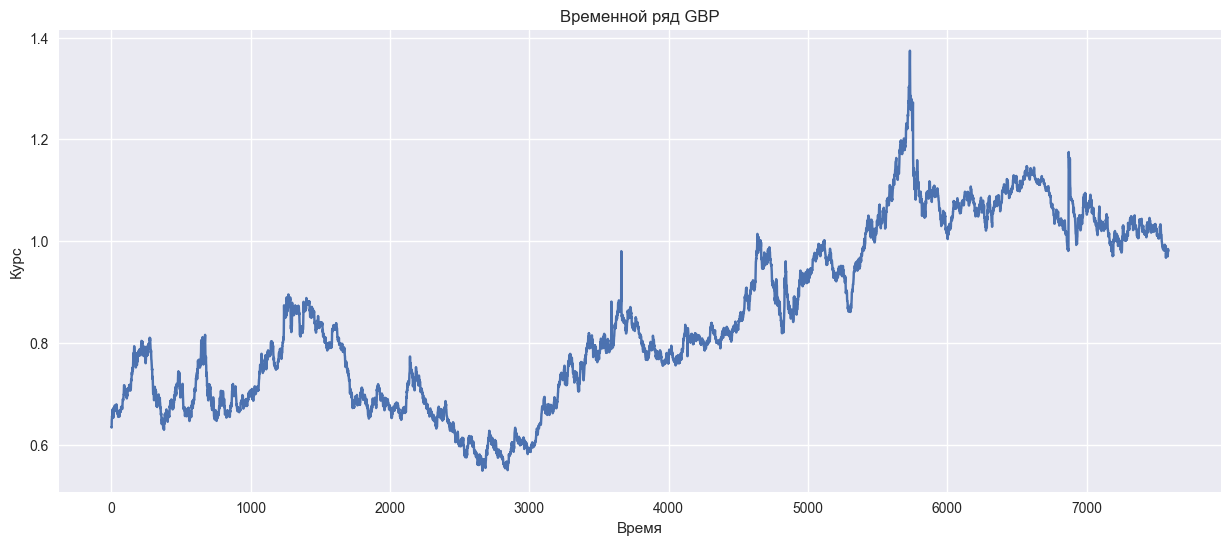

In [50]:
plt.figure(figsize=(15,6))

plt.plot(df['CHF'])
plt.title('Временной ряд GBP')
plt.xlabel('Время')
plt.ylabel('Курс')

plt.show()

На графике временного ряда видно колебания валютного курса во времени. Присутсвуют участки роста и снижения, что может может свидетельтвовать о тренде и нестационарности ряда.

### Анализ ряда (EDA)

1. Стационарность

Проверка стационарности тестом Дики-Фуллера

In [ ]:
alpha = 0.05
name = "CHF"

ts = df["CHF"]

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда CHF :
Test Statistic                   -1.586708
p-value                           0.490267
#Lags Used                       14.000000
Number of Observations Used    7573.000000
Critical Value (1%)              -3.431214
Critical Value (5%)              -2.861922
Critical Value (10%)             -2.566973
dtype: float64
Значение p больше 5.0%. Ряд не стационарный.


2. Тренд


Расчёт 30-периодного скользящего среднего и 95% доверительного интервала на основе скользящего стандартного отклонения и визуализация тренда

C:\Users\Olivia\AppData\Local\Temp\ipykernel_2476\483483749.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g" (-> color=(0.0, 0.5, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(rolling_mean, 'g', label='MA'+str(window),


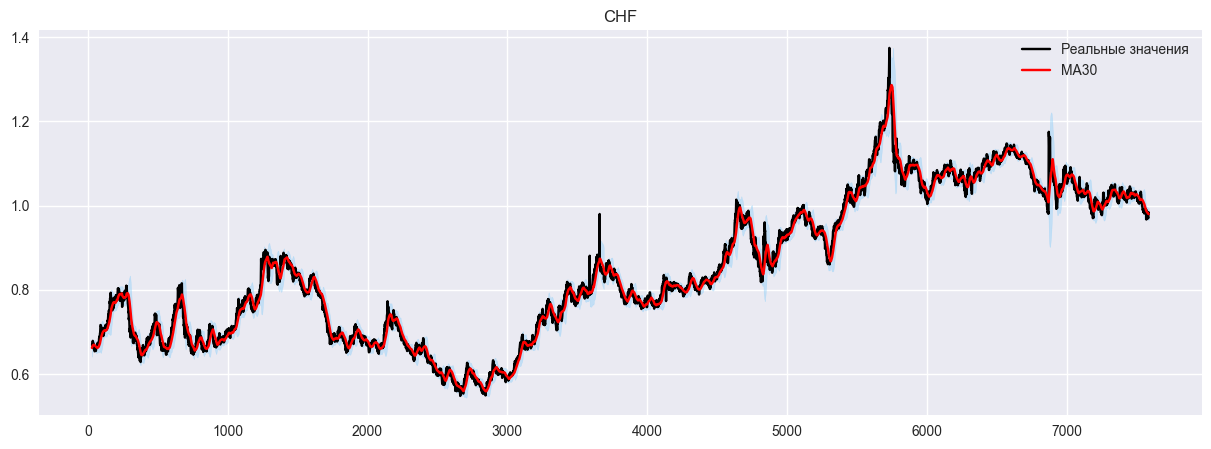

In [52]:
window = 30

# вычисление скользящего среднего и стандартного отклонения
rolling_mean = ts.rolling(window=window).mean()
rolling_std = ts.rolling(window=window).std()

plt.figure(figsize=(15,5))
plt.title(ts.name)
plt.plot(ts[window:], label='Реальные значения', color="black")

plt.plot(rolling_mean, 'g', label='MA'+str(window),
             color="red")

lower_bound = rolling_mean - (1.96 * rolling_std)
upper_bound = rolling_mean + (1.96 * rolling_std)

plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound,
                 color='lightskyblue', alpha=0.4)

plt.legend(loc='best')

plt.grid(True)
plt.show()

Тренд не монотонный, имеет устойчивое долгосрочное повышение.

3. Сезонность

Декомпозиция временного ряда позволяет выделить трендовую, сезонную и случайную компоненты.

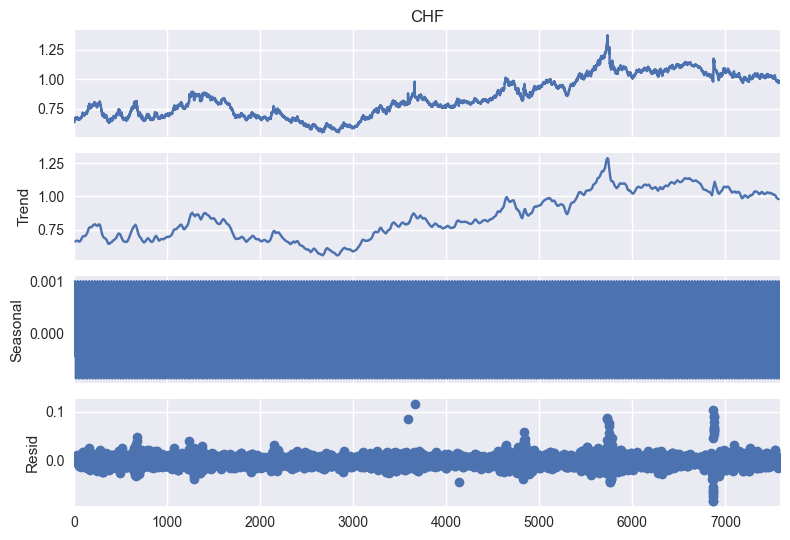

In [53]:
result = seasonal_decompose(df["CHF"], model='additive', period=30)

result.plot()
plt.show()

Для анализа сезонности временного ряда выполнена декомпозиция временного ряда на трендовую, сезонную и случайную составляющие. Сезонная компонента постоянна, что свидетельствует об отсутствии периодических колебаний в ряде.



4. Автокорреляция

<Figure size 1200x700 with 0 Axes>

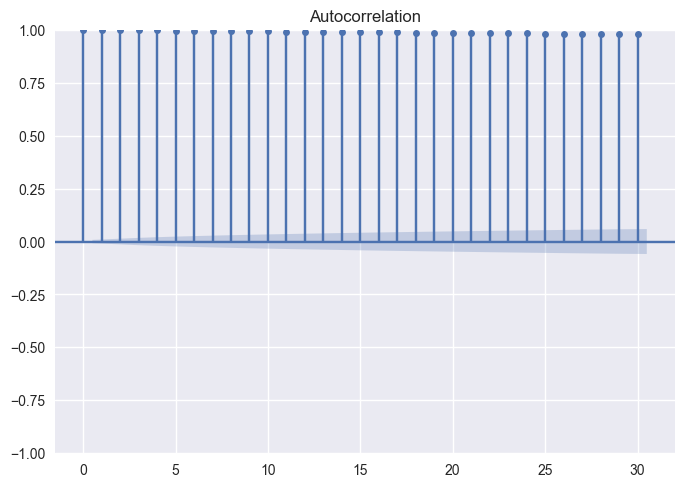

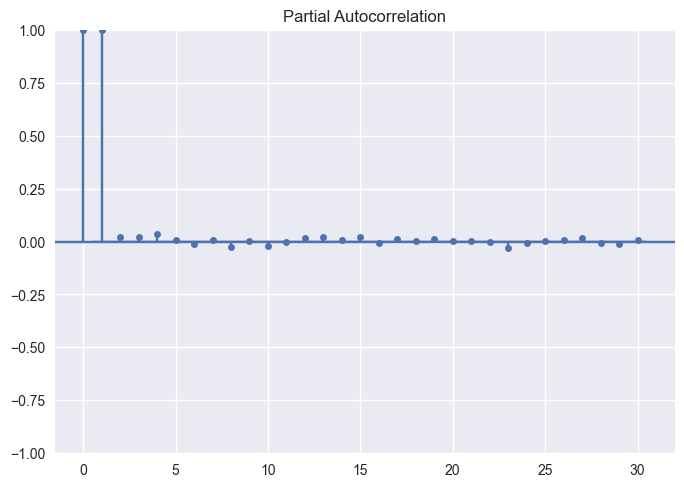

In [54]:
ts = df["CHF"]


fig = plt.figure(figsize=(12, 7))

ac_plot = smt.graphics.plot_acf(ts, lags=30, alpha=0.5)

# частичная автокорреляция
pac_plot = smt.graphics.plot_pacf(ts, lags=30, alpha=0.5)

Текущее значение CHF сильно зависит от предыдущих (особенно от лага 1). Также подверждается отсутствие сезонности, так как никаких периодических пиков на лагах 5, 10, 15, 20, 25, 30 нет.

После удаления тренда получится стационарный ряд, который описывается авторегрессией первого порядка.

5. Выбросы

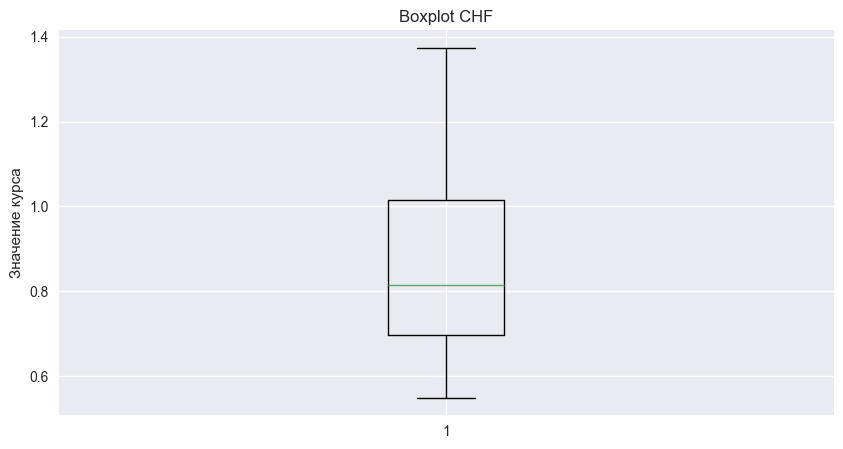

In [55]:

plt.figure(figsize=(10, 5))
plt.boxplot(df['CHF'])
plt.title('Boxplot CHF')
plt.ylabel('Значение курса')
plt.show()

Поиск выбросов через IQR

In [56]:
Q1 = df['CHF'].quantile(0.25)
Q3 = df['CHF'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['CHF'] < lower_bound) | (df['CHF'] > upper_bound)]

print(f"Количество выбросов: {len(outliers)}")
print(f"Доля выбросов: {len(outliers) / len(df) * 100:.2f}%")

Количество выбросов: 0
Доля выбросов: 0.00%


Визуализация выбросов

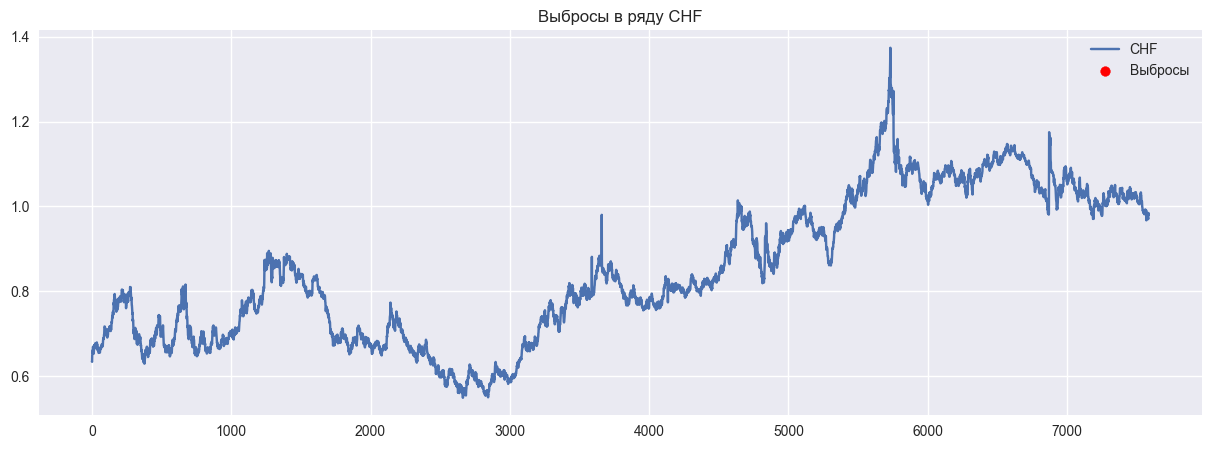

In [57]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df['CHF'], label='CHF')
plt.scatter(
    outliers.index,
    outliers['CHF'],
    color='red',
    label='Выбросы'
)

plt.title('Выбросы в ряду CHF')
plt.legend()
plt.show()

Для нахождения выбросов использован метод межквартильного размаха (IQR). Потенциальными выбросами считались значения, выходящие за пределы интервала:

Q1 − 1.5·IQR

Q3 + 1.5·IQR

Выбросов нет, это свидетельствует о том, что значения временного ряда изменяются плавно и не содержат экстремальных отклонений относительно основнох данных

### Предобработка

1. Scaling

Для нормализации данных используется MinMaxScaler, который приводит признаки к диапазону [0,1].

In [58]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD
0,0.488023,0.445104,0.514050,0.103674,0.792386,0.084053,0.408496,0.005351
1,0.482048,0.443990,0.512794,0.102847,0.792386,0.087651,0.410540,0.000447
2,0.489961,0.465495,0.512638,0.121012,0.792386,0.103771,0.417286,0.008040
3,0.488831,0.474075,0.514835,0.123568,0.792386,0.100604,0.416672,0.000000
4,0.487054,0.491903,0.514678,0.130396,0.792386,0.098733,0.419739,0.011635


Encoding и Interpolation не применялись, так как датасет содержит только числовые признаки и не имеет пропущенных значений.

## Реализация 3 методов извлечения признаков из времянного ряда.

Предсказывается будущие, значитцелевой признак должен быть получен с помощью сдвига временного ряда на 1 шаг, чтобы модели прогнозирования будущее значение временого ряда на основе текущих наблюдений.

In [59]:
df['target'] = df['CHF'].shift(-1)

1. lag features

Прошлые значения ряда

In [60]:
df['CHF_lag1'] = df['CHF'].shift(1)
df['CHF_lag2'] = df['CHF'].shift(2)
df['CHF_lag3'] = df['CHF'].shift(3)

Созданы lag-признаки, содержащие предыдущие значения временного ряда CHF. Они позволяют модели учитывать зависимость текущих значений от прошлых наблюдений.

2. Rolling Statistics

Скользящие статистики.

In [61]:
df['rolling_mean_7'] = df['CHF'].rolling(window=7).mean()

df['rolling_std_7'] = df['CHF'].rolling(window=7).std()

 Рассчет скользящего среднего и скользящего стандартного отклонения с окном 7 наблюдений (умеренное, недельное сглаживание), для выделения локальных закономерностей временного ряда. 

3. Статистические признаки

 Рассчитаны характеристики по всем валютным курсам для каждого временного наблюдения (среднее значение, медиана, стандартное отклонение, минимальное и максимальное значения).

Признаки отражают общее состояние валютного рынка в конкретный момент времени и позволяют учитывать взаимосвязи между различными валютами. В отличие от лаговых признаков и скользящих статистик, которые описывают динамику отдельного временного ряда, статистические признаки характеризуют структуру всего многомерного временного ряда.

In [62]:
currency_cols = [
    'AUD',
    'GBP',
    'CAD',
    'CHF',
    'CNY',
    'JPY',
    'NZD',
    'SGD'
]

df['mean_all'] = df[currency_cols].mean(axis=1)
df['std_all'] = df[currency_cols].std(axis=1)
df['min_all'] = df[currency_cols].min(axis=1)
df['max_all'] = df[currency_cols].max(axis=1)
df['median_all'] = df[currency_cols].median(axis=1)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AUD             7588 non-null   float64
 1   GBP             7588 non-null   float64
 2   CAD             7588 non-null   float64
 3   CHF             7588 non-null   float64
 4   CNY             7588 non-null   float64
 5   JPY             7588 non-null   float64
 6   NZD             7588 non-null   float64
 7   SGD             7588 non-null   float64
 8   target          7587 non-null   float64
 9   CHF_lag1        7587 non-null   float64
 10  CHF_lag2        7586 non-null   float64
 11  CHF_lag3        7585 non-null   float64
 12  rolling_mean_7  7582 non-null   float64
 13  rolling_std_7   7582 non-null   float64
 14  mean_all        7588 non-null   float64
 15  std_all         7588 non-null   float64
 16  min_all         7588 non-null   float64
 17  max_all         7588 non-null   f

Появились NaN, поэтому их нужно удалить для будущего обучения.

In [64]:
df = df.dropna()

In [65]:
df.head()

,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD,target,CHF_lag1,CHF_lag2,CHF_lag3,rolling_mean_7,rolling_std_7,mean_all,std_all,min_all,max_all,median_all
6,0.7886,1.6620,0.862887,0.661157,0.211242,0.006885,0.6070,0.527565,0.659631,0.654879,0.656254,0.650618,0.648446,0.010760,0.665917,0.494212,0.006885,1.6620,0.634078
7,0.7910,1.6568,0.864304,0.659631,0.211242,0.006878,0.6084,0.527565,0.669120,0.661157,0.654879,0.656254,0.652080,0.009348,0.665728,0.492864,0.006878,1.6568,0.634016
8,0.7939,1.6695,0.864230,0.669120,0.211242,0.006878,0.6115,0.528123,0.659413,0.659631,0.661157,0.654879,0.657167,0.006938,0.669312,0.496533,0.006878,1.6695,0.640310
9,0.7894,1.6570,0.858369,0.659413,0.211242,0.006874,0.6090,0.528123,0.663702,0.669120,0.659631,0.661157,0.658725,0.005801,0.664928,0.492495,0.006874,1.6570,0.634207
10,0.7917,1.6495,0.859107,0.663702,0.211242,0.006873,0.6120,0.529381,0.658545,0.659413,0.669120,0.659631,0.660594,0.004769,0.665438,0.490364,0.006873,1.6495,0.637851


In [1]:
df.info()

NameError: name 'df' is not defined

## Моделирование

### Классическая ML модель (Random Forest)

Деление на X и Y

In [66]:
X = df.drop(columns=['target'])
y = df['target']

X:

валюты

lag features

rolling features

mean_all

std_all
        
min_all 

max_all  
       
median_all      

y:

будущий CHF.

Разделение выборки на Train/Test пропорции 80% / 20%. Данные не перемешиваютсся.

In [67]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [68]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Метрики

MAE - средняя ошибка 

RMSE - корень из среднеквадратичной ошибки, показывает устойчивость к большим ошибкам.

R² - насколько хорошо модель объясняет поведение временного ряда.

In [69]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 0.004715409057350065
RMSE: 0.007243118961230004
R2: 0.97121218421565


### Нейросетевые структуры (LSTM и GRU)

Формат данных приведён к виду (samples, timesteps, features), для работы рекуррентных нейронных сетей Keras. 1 объект - последовательность длиной один временной шаг.

In [70]:
X_train_nn = np.array(X_train)
X_test_nn = np.array(X_test)

X_train_nn = X_train_nn.reshape(
    X_train_nn.shape[0],
    1,
    X_train_nn.shape[1]
)

X_test_nn = X_test_nn.reshape(
    X_test_nn.shape[0],
    1,
    X_test_nn.shape[1]
)

1. LSTM

In [ ]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(
            X_train_nn.shape[1],
            X_train_nn.shape[2]
        )
    )
)   

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history = lstm_model.fit(
    X_train_nn,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


c:\Users\Olivia\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0311 - val_loss: 0.0280
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018 - val_loss: 0.0144
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.7899e-04 - val_loss: 0.0038
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7601e-04 - val_loss: 6.0373e-04
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0411e-04 - val_loss: 2.1887e-04
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5299e-04 - val_loss: 2.1728e-04
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2806e-04 - val_loss: 1.9314e-04
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0977e-04 - val_loss: 1.9253e-04
Epoch 9/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.7613e-05 - val_loss: 2.0237e-04
Epoch 10/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.0120e-05 - val_loss: 1.9866e-04
Epoch 11/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.4937e-05 - val_loss: 1.8878

In [72]:
lstm_pred = lstm_model.predict(X_test_nn)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [73]:
lstm_mae = mean_absolute_error(y_test, lstm_pred)

lstm_rmse = np.sqrt(
    mean_squared_error(y_test, lstm_pred)
)

lstm_r2 = r2_score(y_test, lstm_pred)

print("LSTM")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2:", lstm_r2)

LSTM
MAE: 0.006531839135365496
RMSE: 0.01024737726572117
R2: 0.9423787162802647


2. GRU

In [ ]:
gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        activation='tanh',
        input_shape=(
            X_train_nn.shape[1],
            X_train_nn.shape[2]
        )
    )
)

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train_nn,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


c:\Users\Olivia\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0127 - val_loss: 0.0177
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.3945e-04 - val_loss: 0.0019
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6544e-04 - val_loss: 3.9604e-04
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7824e-04 - val_loss: 2.6218e-04
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4027e-04 - val_loss: 2.7509e-04
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1147e-04 - val_loss: 2.1774e-04
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0100e-04 - val_loss: 2.0058e-04
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.5990e-05 - val_loss: 1.9849e-04
Epoch 9/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.3933e-05 - val_loss: 2.1358e-04
Epoch 10/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.9323e-05 - val_loss: 1.9244e-04
Epoch 11/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.6343e-05 - val_loss

In [75]:
gru_pred = gru_model.predict(X_test_nn)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [76]:
gru_mae = mean_absolute_error(y_test, gru_pred)

gru_rmse = np.sqrt(
    mean_squared_error(y_test, gru_pred)
)

gru_r2 = r2_score(y_test, gru_pred)

print("GRU")
print("MAE:", gru_mae)
print("RMSE:", gru_rmse)
print("R2:", gru_r2)

GRU
MAE: 0.008049008392985273
RMSE: 0.01126472701872063
R2: 0.930369610860479


## Анализ результатов и выводы.

1. Сравнительная таблица для наглядного сравнения модели по ключевым метрикам

In [77]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'LSTM', 'GRU'],
    
    'MAE': [
        rf_mae,
        lstm_mae,
        gru_mae
    ],
    
    'RMSE': [
        rf_rmse,
        lstm_rmse,
        gru_rmse
    ],
    
    'R2': [
        rf_r2,
        lstm_r2,
        gru_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Random Forest,0.004715,0.007243,0.971212
1,LSTM,0.006532,0.010247,0.942379
2,GRU,0.008049,0.011265,0.930370


2. Определение лучшей модели

In [78]:
best_model = results.loc[
    results['RMSE'].idxmin()
]

print(best_model)

Model    Random Forest
MAE           0.004715
RMSE          0.007243
R2            0.971212
Name: 0, dtype: object


Наименьшая средняя ошибка MAE, наименьший корень из среднеквадратичной ошибки RMSE и найбольший коэфициент детерминации R² у модели Random Forest, а значит Random Forest в данном случае наилучшая модель.

Несмотря на использование рекуррентных нейронных сетей LSTM и GRU, наилучшие результаты показала модель Random Forest. Возможные причины:

1. После этапа feature extraction, во время которого временные зависимости были представлены в явном виде с помощью лаговых признаков, скользящих статистик и статистических характеристик, значительная часть информации о структуре временного ряда уже содержалась в сформированном наборе признаков.

2. Задача стала похожа к классической задаче табличной регрессии, где строки это объекты, а столбцы - признаки, с которой Random Forest прекрасно справляется.

3. Нейросетевые архитектуры требуют более тонкой настройки гиперпараметров и большего объема данных, к тому же использовались последовательности длиной в 1 временной шаг, поэтому их способность выявлять долгосрочные временные зависимости не полностью реализована.